# 0. Importing Libraries

In [685]:
#-----Data Wrangling and Analysis-----

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----Machine Learning-----

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score

#-----Deep Learning-----




## initizalizing the paths and other important things that we would require during training or loading

In [686]:
DATA_PATH = "../data/house_price/data.csv"
# DATA_PATH_2 = "../data/house_price/output.csv" same as the org data

# 1. Data Loading

In [687]:
df = pd.read_csv(DATA_PATH)
# df_2 = pd.read_csv(DATA_PATH_2)

In [688]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [689]:
df.shape

(4600, 18)

In [690]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [691]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [692]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [693]:
df.describe(include="object")

,date,street,city,statezip,country
count,4600,4600,4600,4600,4600
unique,70,4525,44,77,1
top,2014-06-23 00:00:00,2520 Mulberry Walk NE,Seattle,WA 98103,USA
freq,142,4,1573,148,4600


# Data Cleaning

In [694]:
# As the date was in object format, converted it into datetime format

df["date"] = pd.to_datetime(df["date"])

In [695]:
# Removing unnessary columns

df.drop(columns=["street", "country"], inplace=True)

In [696]:
print(df.statezip.value_counts())

statezip
WA 98103    148
WA 98052    135
WA 98117    132
WA 98115    130
WA 98006    110
           ... 
WA 98047      6
WA 98288      3
WA 98050      2
WA 98354      2
WA 98068      1
Name: count, Length: 77, dtype: int64


In [697]:
df[["state", "zipcode"]] = df["statezip"].str.split(" ", expand=True)

df.drop(columns=["state", "statezip"], inplace=True)

In [698]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'zipcode'],
      dtype='object')

In [699]:
df.isna().sum()


date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
city             0
zipcode          0
dtype: int64

In [700]:
df.duplicated().sum()

np.int64(0)

In [701]:
df.nunique()

date               70
price            1741
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
city               44
zipcode            77
dtype: int64

In [702]:
# Inspecting the statement "Most of the data in the dataset is 0 that may affect the data" in the discussion tab 

count = 0
for i in df.price:

    if i == 0:
        count += 1
       
print(count)       


49


In [703]:
df = df[df["price"] > 0]

In [704]:
df = df[df["price"] < 20_000_000]

# Feature Engineering

In [705]:
# Getting the infromation weather the house is renewed or not

df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)

In [706]:
# Age of the house

sale_year = df["date"].dt.year

df["house_age"] = sale_year - df["yr_built"]

In [707]:
# Years since renovation

df["years_since_renovation"] = np.where(
    df["yr_renovated"] == 0,
    0,
    sale_year - df["yr_renovated"]
)

In [708]:
# Date features

df["sale_year"] = sale_year
df["sale_month"] = df["date"].dt.month




In [709]:
# Total square footage

df["total_sqft"] = (
    df["sqft_above"] +
    df["sqft_basement"]
)

In [710]:

# EDA-only feature

df["price_per_sqft"] = (
    df["price"] /
    df["sqft_living"]
)

In [711]:
df_categorical_features = [
    "waterfront",
    "view",
    "condition",
    "floors",
    "city",
    "zipcode",
    "is_renovated"
]

df_numerical_features = [
    col for col in df.columns
    if col not in df_categorical_features + ["price", "date"]
]

In [712]:
df_categorical_features

['waterfront',
 'view',
 'condition',
 'floors',
 'city',
 'zipcode',
 'is_renovated']

In [713]:
df_numerical_features

['bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'house_age',
 'years_since_renovation',
 'sale_year',
 'sale_month',
 'total_sqft',
 'price_per_sqft']


# Performing Exploratory Data Analysis (EDA)

In [714]:
# Getting overall stats of price our target feature

df["price"].describe()

count    4.550000e+03
mean     5.521846e+05
std      4.111969e+05
min      7.800000e+03
25%      3.261821e+05
50%      4.650000e+05
75%      6.575000e+05
max      1.289900e+07
Name: price, dtype: float64

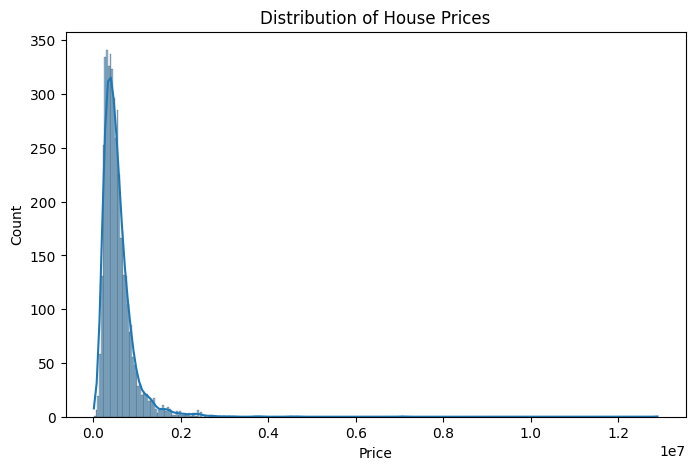

In [715]:
# The normal histogram without logrithmic transformation 

plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.show()

Earlier we observed that the data was highly right skewed making it incompabilble for analysis, use of log transformation to reduce the sharp or extreme values giving us a roughly symmetric observation

Smart to use the log transformed data instead of original as the model may try very hard to fit those multi million dollar house

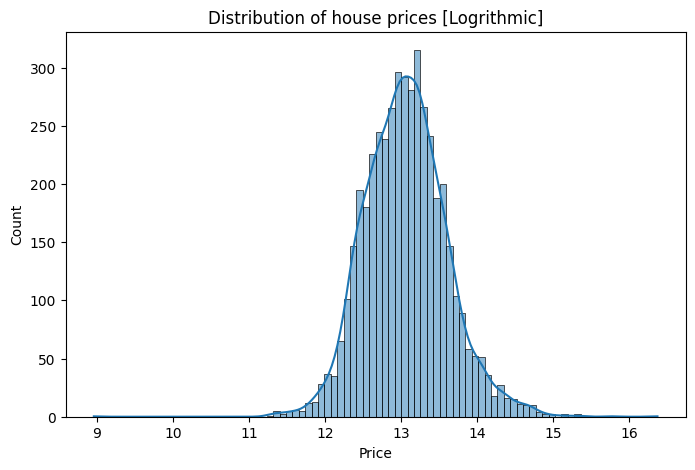

In [716]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["price"]), kde=True)
plt.title("Distribution of house prices [Logrithmic]")
plt.xlabel("Price")
plt.show()

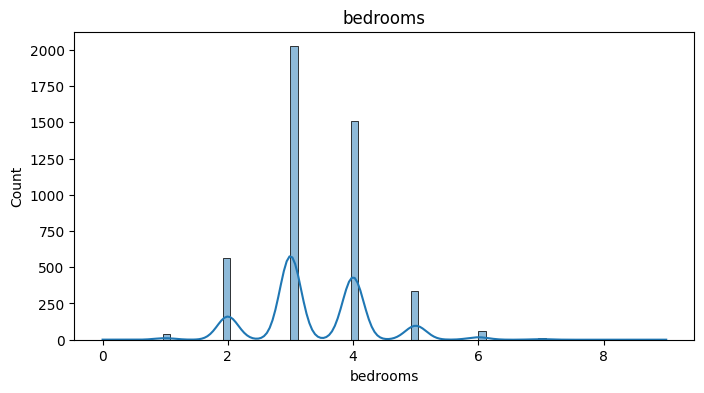

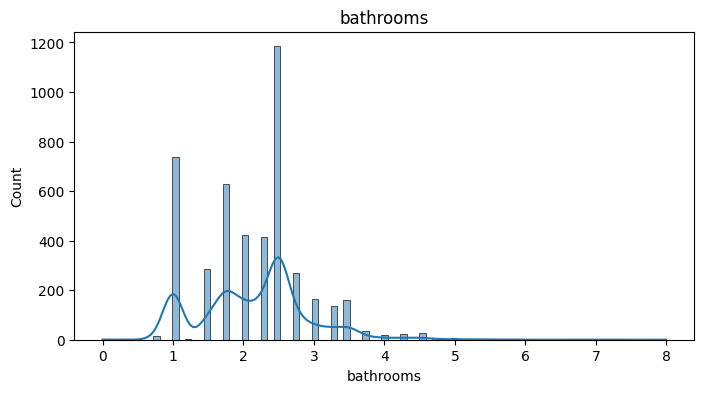

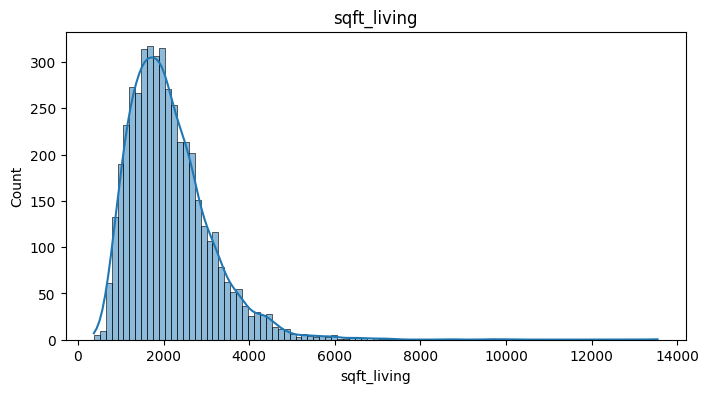

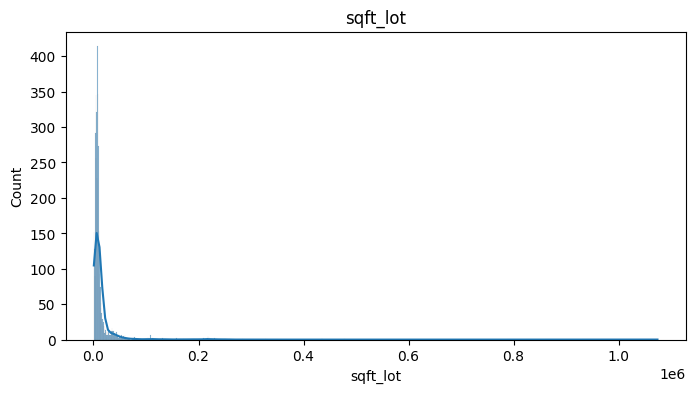

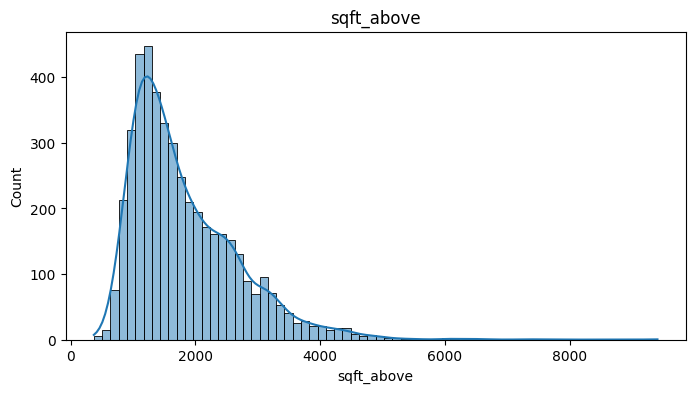

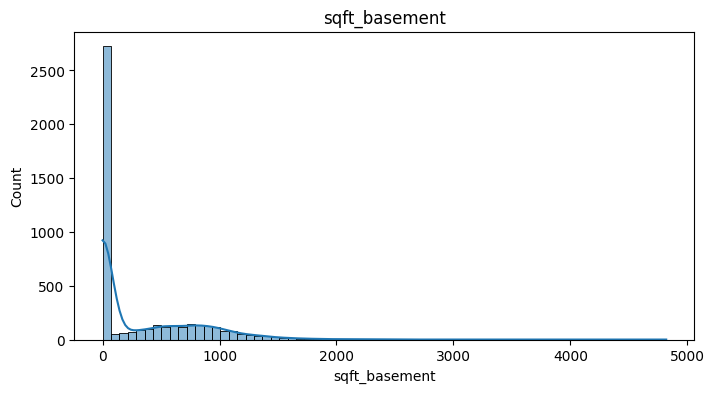

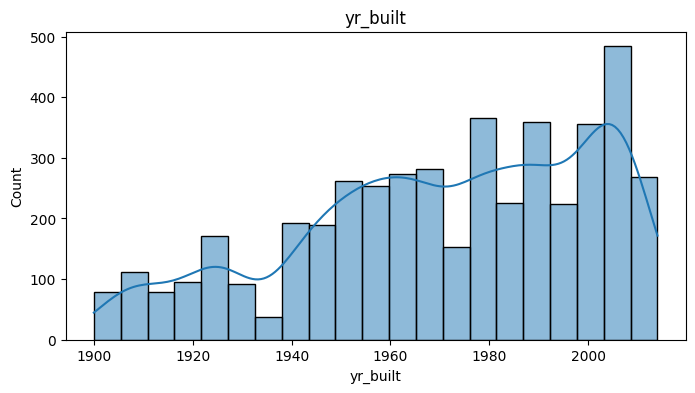

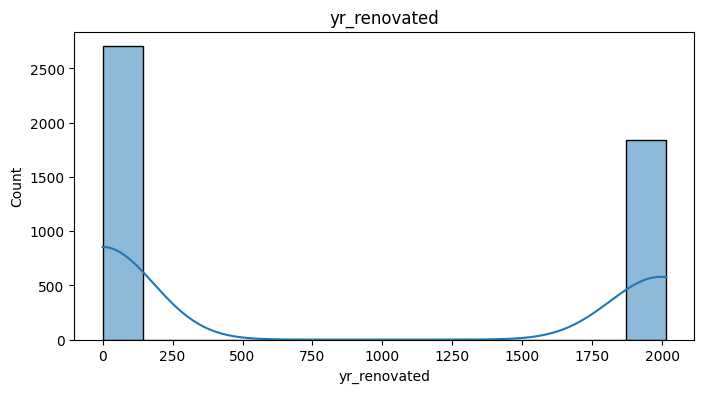

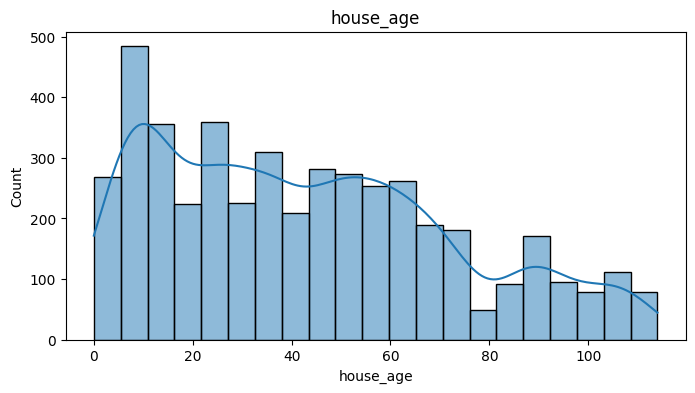

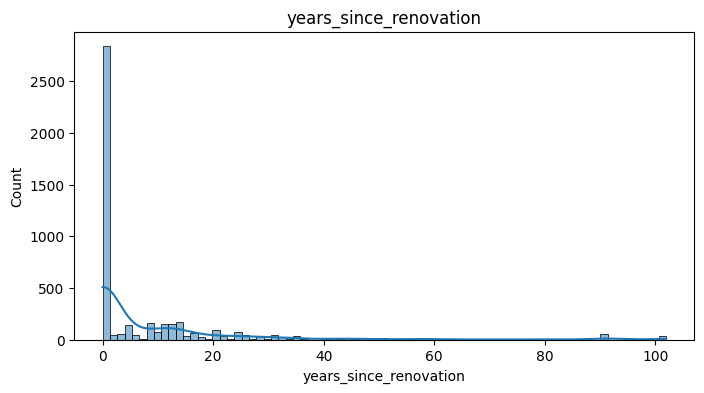

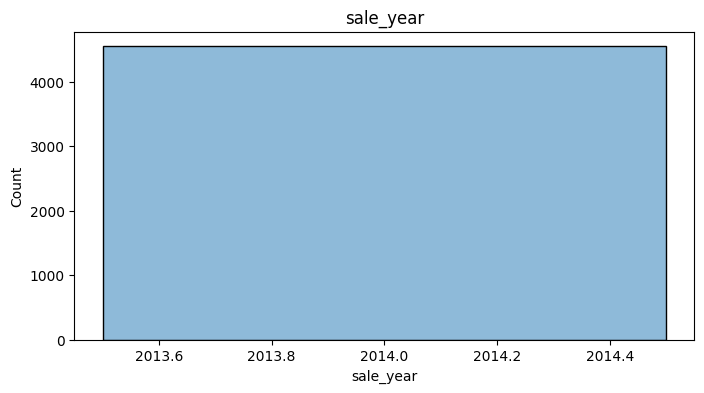

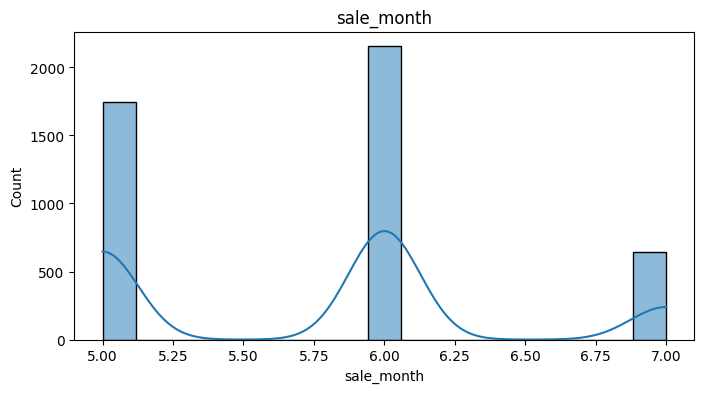

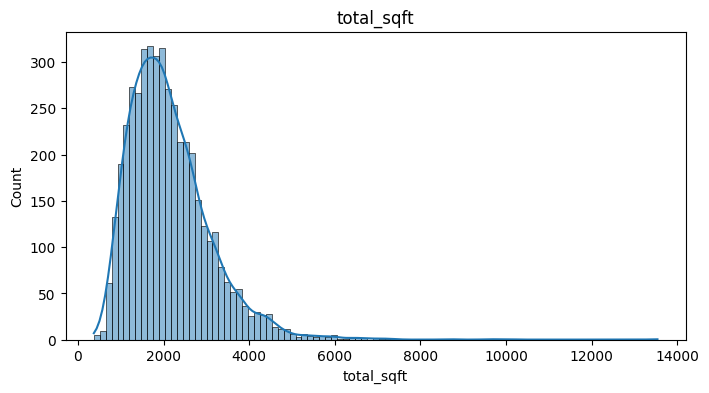

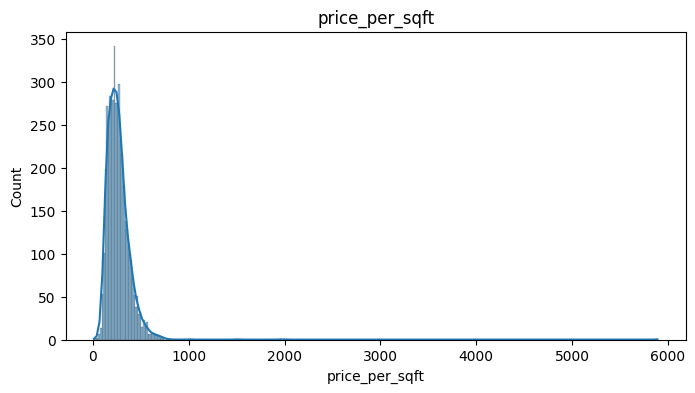

In [717]:
for col in df_numerical_features:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

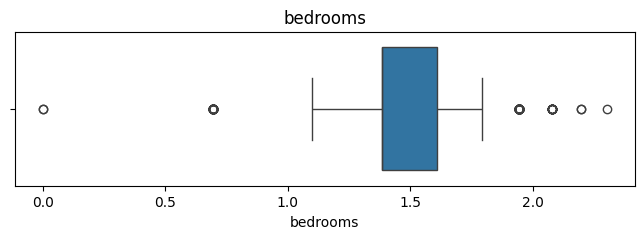

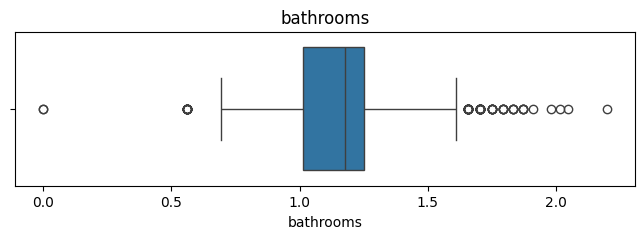

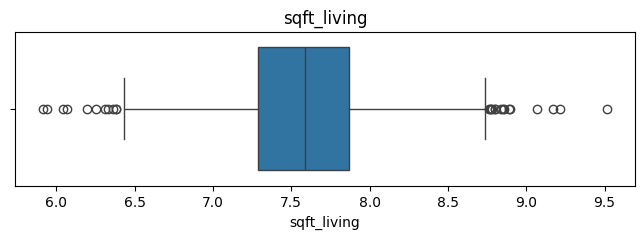

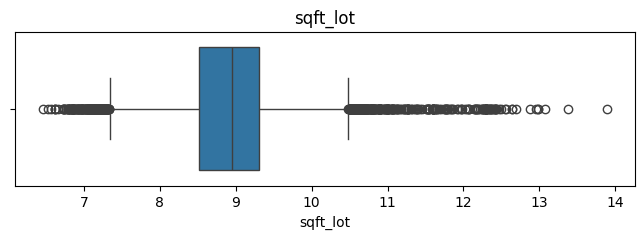

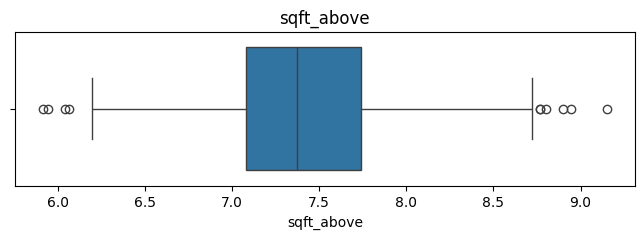

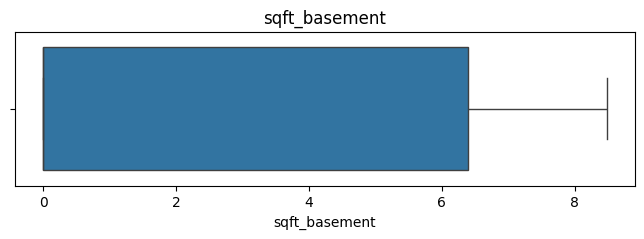

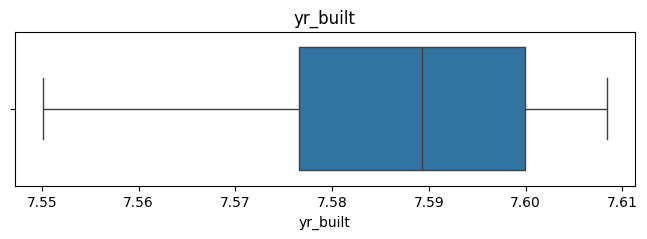

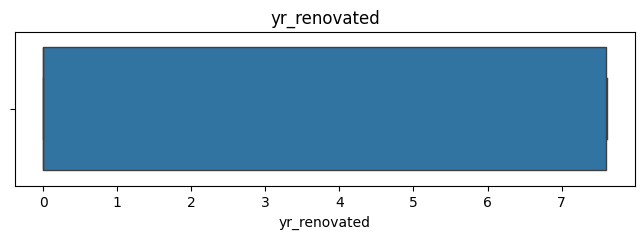

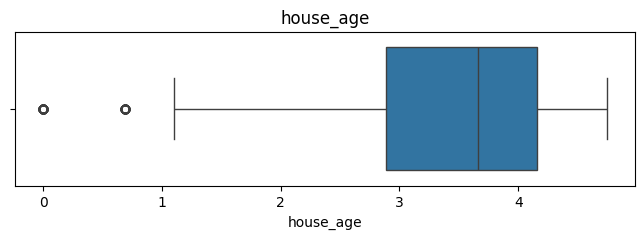

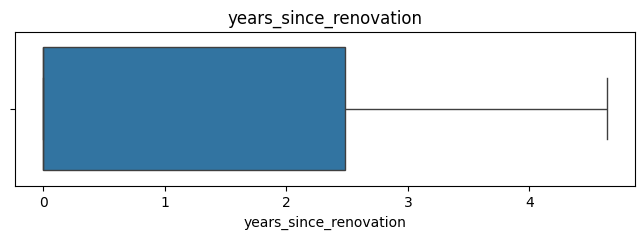

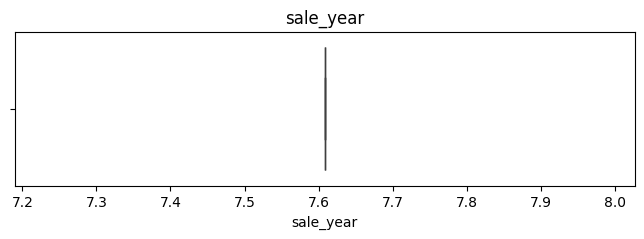

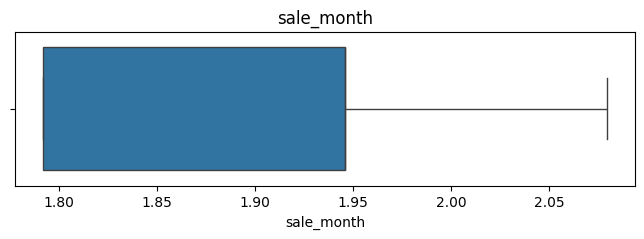

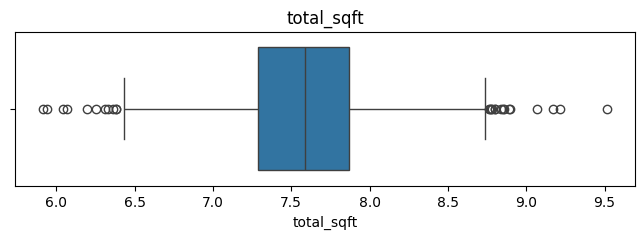

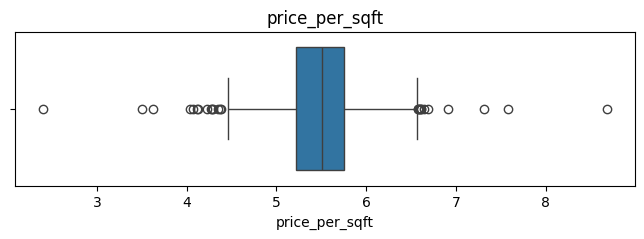

In [718]:
for col in df_numerical_features:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=np.log1p(df[col]))
    plt.title(col)
    plt.show()

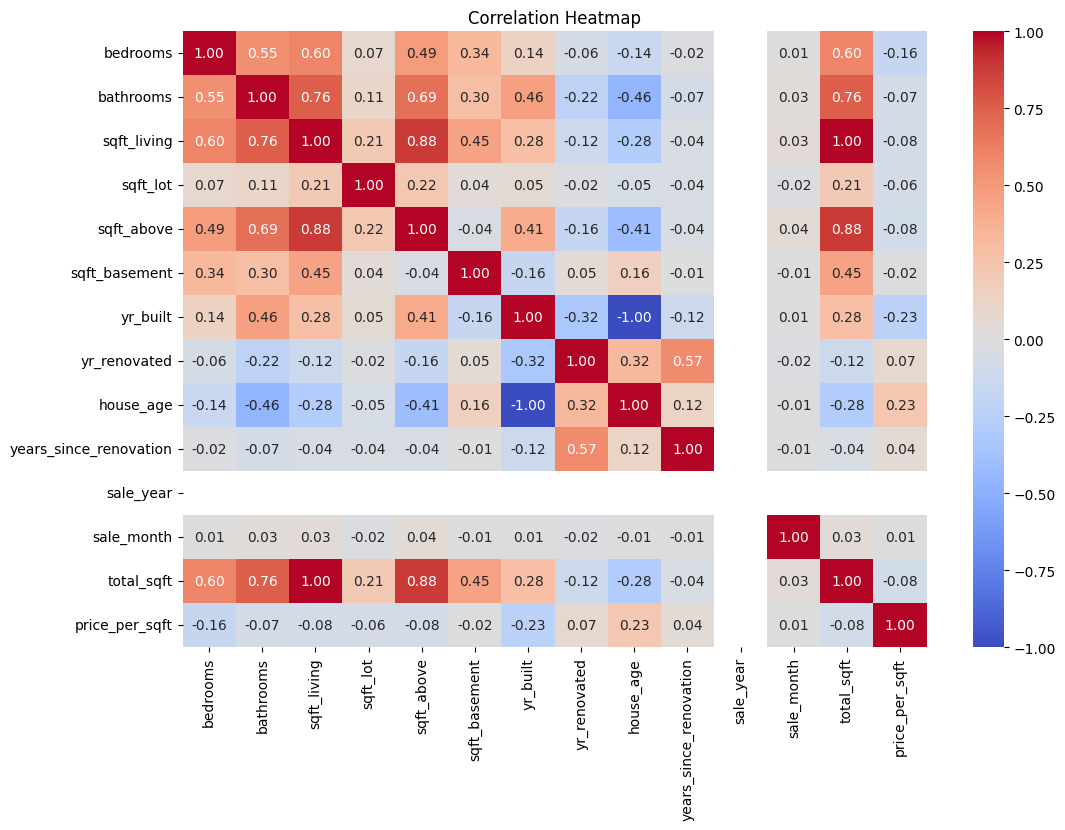

In [719]:
plt.figure(figsize=(12,8))
corr = df[df_numerical_features].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

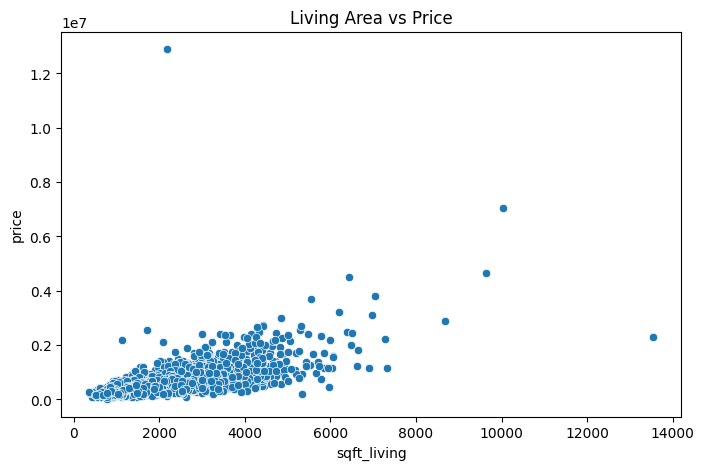

In [720]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="sqft_living",
                y="price",
                data=df)

plt.title("Living Area vs Price")
plt.show()

Smaller cities have relatively few observations, which may make it harder for the model to accurately learn city-specific pricing patterns for those locations.

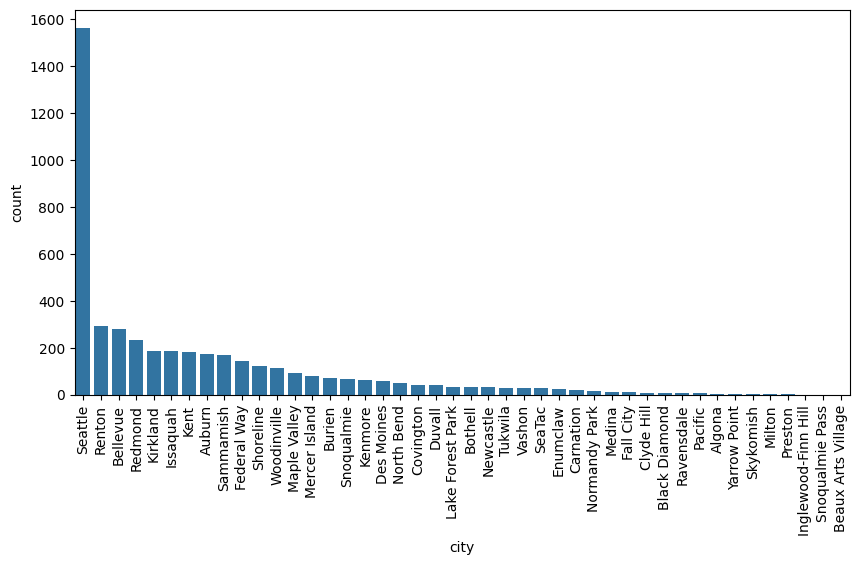

In [721]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,
              x="city",
              order=df["city"].value_counts().index)

plt.xticks(rotation=90)
plt.show()

Average house prices vary across cities, suggesting that location is an important factor influencing property value.

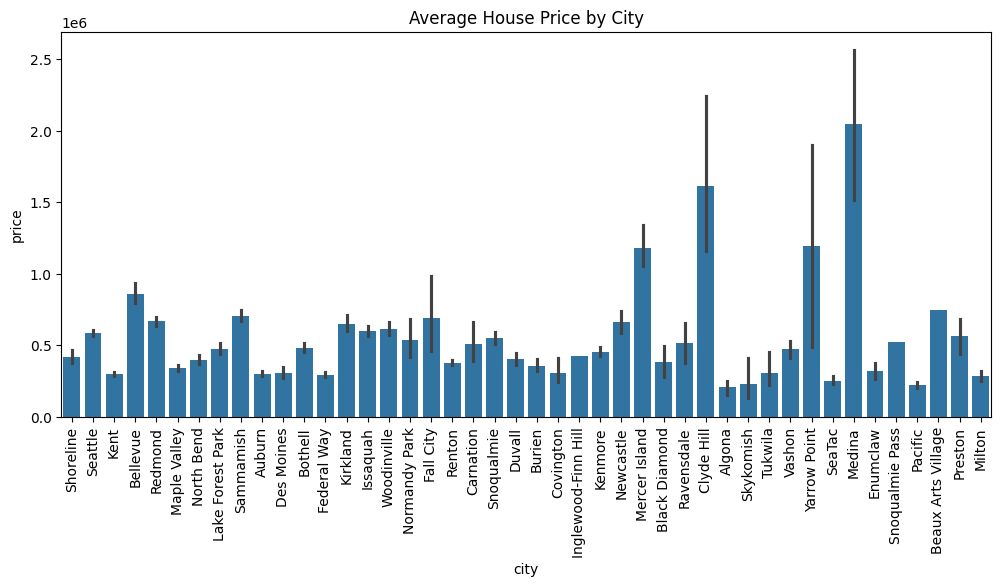

In [722]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=df,
    x="city",
    y="price",
    estimator="mean"
)

plt.xticks(rotation=90)
plt.title("Average House Price by City")
plt.show()

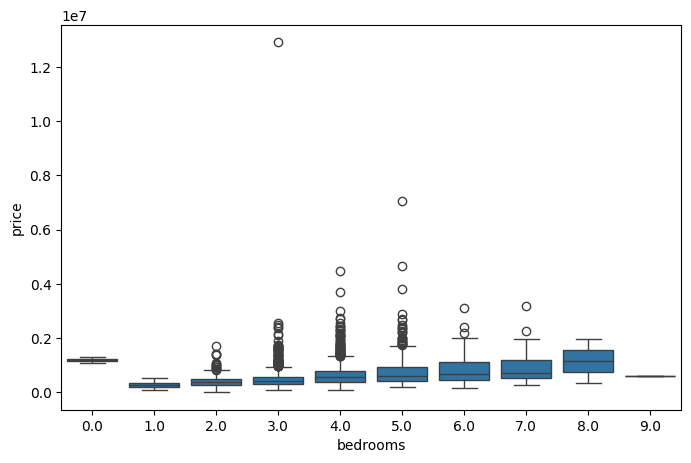

In [723]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="bedrooms",
    y="price"
)

plt.show()

In [724]:
corr = df.corr(numeric_only=True)

corr["price"].sort_values(ascending=False)

price                     1.000000
price_per_sqft            0.661352
sqft_living               0.624967
total_sqft                0.624967
sqft_above                0.532604
bathrooms                 0.470665
view                      0.337001
sqft_basement             0.308066
bedrooms                  0.294423
floors                    0.222781
waterfront                0.206985
sqft_lot                  0.073153
condition                 0.041995
sale_month                0.030304
yr_built                  0.019925
years_since_renovation   -0.000231
house_age                -0.019925
is_renovated             -0.028066
yr_renovated             -0.028334
sale_year                      NaN
Name: price, dtype: float64

In [725]:
corr = df.corr(numeric_only=True)

corr["price"].sort_values(ascending=False)

price                     1.000000
price_per_sqft            0.661352
sqft_living               0.624967
total_sqft                0.624967
sqft_above                0.532604
bathrooms                 0.470665
view                      0.337001
sqft_basement             0.308066
bedrooms                  0.294423
floors                    0.222781
waterfront                0.206985
sqft_lot                  0.073153
condition                 0.041995
sale_month                0.030304
yr_built                  0.019925
years_since_renovation   -0.000231
house_age                -0.019925
is_renovated             -0.028066
yr_renovated             -0.028334
sale_year                      NaN
Name: price, dtype: float64

In [726]:
# Remove Temporary Features

drop_columns = [
    "date",
    "sale_year",
    "yr_built",
    "yr_renovated",
    "sqft_above",
    "sqft_basement",
]

df.drop(columns=drop_columns, inplace=True)

In [727]:
df.drop(columns="price_per_sqft", inplace=True)

In [728]:
df_categorical_features = [
    "waterfront",
    "view",
    "condition",
    "floors",
    "city",
    "zipcode",
    "is_renovated"
]

df_numerical_features = [
    col for col in df.columns
    if col not in df_categorical_features + ["price", "date"]
]

# Train Test Split

In [729]:
X = df.drop(columns='price')
y = np.log1p(df['price'])

In [730]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [731]:
df_categorical_features

['waterfront',
 'view',
 'condition',
 'floors',
 'city',
 'zipcode',
 'is_renovated']

In [732]:
# Preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), df_numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), df_categorical_features)
    ]
)

In [733]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

In [734]:
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    print(f"----{name}---- \n")
    print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred)}")
    print(f"Root Mean Squared Error (RMSE): {root_mean_squared_error(y_test, y_pred)}")
    print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred)}")
    print(f"r2 Score (R2): {r2_score(y_test, y_pred)} \n")

----Linear Regression---- 

Mean Squared Error (MSE): 0.07179948571192697
Root Mean Squared Error (RMSE): 0.26795426048474574
Mean Absolute Error (MAE): 0.16807423826372983
r2 Score (R2): 0.7641297585704854 

----Decision Tree---- 

Mean Squared Error (MSE): 0.1508510143578137
Root Mean Squared Error (RMSE): 0.3883954355522393
Mean Absolute Error (MAE): 0.25369298007495933
r2 Score (R2): 0.5044356540487851 

----Random Forest---- 

Mean Squared Error (MSE): 0.08293805565853055
Root Mean Squared Error (RMSE): 0.2879896797778187
Mean Absolute Error (MAE): 0.18621547060473104
r2 Score (R2): 0.7275381708114035 

----Gradient Boosting---- 

Mean Squared Error (MSE): 0.08328617725712756
Root Mean Squared Error (RMSE): 0.2885934463170076
Mean Absolute Error (MAE): 0.20106655214656247
r2 Score (R2): 0.7263945480584864 



In [735]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    print(f"{name}")
    print(f"Mean R²: {scores.mean():.4f}")
    print(f"Std Dev: {scores.std():.4f}\n")

Linear Regression
Mean R²: 0.7977
Std Dev: 0.0227

Decision Tree
Mean R²: 0.5498
Std Dev: 0.0402

Random Forest
Mean R²: 0.7434
Std Dev: 0.0165

Gradient Boosting
Mean R²: 0.7424
Std Dev: 0.0223



In [736]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)

In [737]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred)

In [738]:
print("MAE :", mean_absolute_error(y_test_actual, y_pred_actual))
print("RMSE:", root_mean_squared_error(y_test_actual, y_pred_actual))
print("R²  :", r2_score(y_test, y_pred))

MAE : 134652.5302130538
RMSE: 796400.415563388
R²  : 0.7641297585704854


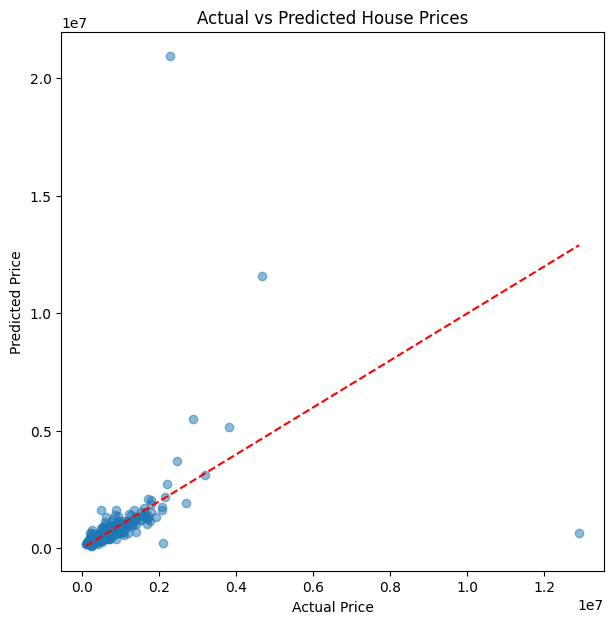

In [739]:
plt.figure(figsize=(7,7))

plt.scatter(y_test_actual, y_pred_actual, alpha=0.5)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

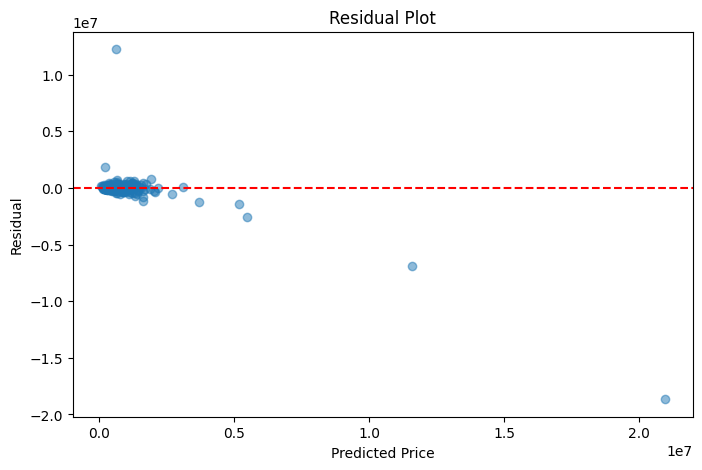

In [740]:
residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(8,5))

plt.scatter(y_pred_actual, residuals, alpha=0.5)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [741]:
import joblib

joblib.dump(final_pipeline, "house_price_pipeline.pkl")

['house_price_pipeline.pkl']